<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab8_RNN_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 8: RNN-Based Text Classification

Classifying IMDB movie reviews as positive or negative using a recurrent network.

Every practical so far fed the network a **fixed set of features**: three sensor readings, twelve chemical measurements, a 32x32 image. A review is different. It is a **sequence** of variable length, and the order of the words is part of the meaning. "Not good at all" and "good, not at all bad" share most of their words.

An RNN handles this by reading one word at a time and carrying a **hidden state** forward, so what it has read so far influences how it reads the next word. That memory is the new idea in this practical.

**Pipeline:** review text, tokenise to integers, pad to a fixed length, Embedding turns each word id into a vector, SimpleRNN reads the sequence and outputs one summary vector, Dense with sigmoid gives the probability the review is positive.

## What changes from the previous practicals

| | Practicals 4, 6, 7 (MLP) | Practical 5 (CNN) | Practical 8 (RNN) |
|---|---|---|---|
| Input | fixed feature vector | fixed 2D grid | **variable-length sequence** |
| First layer | `Dense` | `Conv2D` | **`Embedding` then `SimpleRNN`** |
| Weight reuse | none | across **positions in space** | across **positions in time** |
| Output | softmax or linear | sigmoid | sigmoid |

Practical 5's lesson transfers directly and is worth carrying in. A `Dense` layer learns a pattern at one position and cannot reuse it elsewhere; a convolution slides one filter across every position and so learns the pattern once. **An RNN does the same trick along time**: the same weights are applied at every timestep. The word "terrible" is recognised as negative whether it appears at word 5 or word 150, because the same weight matrix processes both.

The genuinely new part is the hidden state, which a CNN does not have. The network carries information forward from earlier words, which is what makes order matter at all.

## Task 1: Load and explore the dataset

**Dataset:** IMDB Large Movie Review Dataset (Maas et al., 2011), 50,000 movie reviews labelled positive or negative, balanced by construction.

**Source:** the raw-text CSV distribution of the same dataset, `https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv`, downloaded automatically the first time the notebook runs.

**Why raw text instead of `tensorflow.keras.datasets.imdb`.** It is the same dataset, but `imdb.load_data(num_words=10000)` arrives already tokenised, which hides exactly the steps Task 2 asks for: building the vocabulary, ranking words by frequency, mapping words to integers, and handling words outside the vocabulary. Starting from raw text makes every one of those steps visible. The encoding copies Keras's conventions (0 for padding, 1 for the start marker, 2 for out-of-vocabulary, real words from 3), so the final arrays have the same format `load_data` produces.

For reference, the pre-tokenised route is one line: `tf.keras.datasets.imdb.load_data(num_words=10000)`.

In [ ]:
import numpy as np, pandas as pd, re, collections, time, os, urllib.request
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.sparse import csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

VOCAB_SIZE = 10000      # as specified
MAX_LEN    = 200        # as specified
PAD, START, OOV, INDEX_FROM = 0, 1, 2, 3

DATA_FILE = "IMDB-Dataset.csv"
DATA_URL  = "https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv"
if not os.path.exists(DATA_FILE):          # first run only, e.g. a fresh Colab session
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

raw = pd.read_csv(DATA_FILE)
print("raw reviews loaded :", raw.shape)
print("label counts       :", raw['sentiment'].value_counts().to_dict())
print("duplicate rows     :", raw.duplicated().sum())

df = raw.drop_duplicates().reset_index(drop=True)
print("after dropping duplicates:", df.shape)
print("\nexample review (first 250 characters):")
print(df['review'].iloc[0][:250])
print("\nlabel:", df['sentiment'].iloc[0])

raw reviews loaded : (50000, 2)
label counts       : {'positive': 25000, 'negative': 25000}
duplicate rows     : 418


after dropping duplicates: (49582, 2)

example review (first 250 characters):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of 

label: positive


#### Observation
50,000 reviews, exactly 25,000 positive and 25,000 negative, so the classes are balanced and plain accuracy is a fair metric here.

418 reviews appear more than once. They are dropped **before** the train/test split, because a duplicate landing on both sides would let the model be tested on a review it had already memorised. In Practical 7 the same kind of leak was worth 1.7 points of fake accuracy.

## Task 2: Data preprocessing

Five steps, each of which `imdb.load_data()` would normally do invisibly.

**1. Tokenise.** Lowercase, strip the `<br />` HTML tags that litter this dataset, and split into words. Without removing the tags, "br" becomes one of the most frequent tokens in the corpus and wastes a vocabulary slot on nothing.

**2. Split into train and test**, 50/50, the same proportion as the official IMDB split. The CSV does not record which official half each review came from, so the split is random (seeded for reproducibility). Duplicates were already removed, so the same review can never sit on both sides of the split.

**3. Build the vocabulary from the training half only.** A vocabulary of 10,000 indices: the 9,997 most frequent training words plus the three reserved markers. Building it from all 50,000 reviews would let test-set word frequencies shape the model, a small but real leak.

**4. Convert reviews to integer sequences.** Every word becomes its frequency-rank index. Words outside the vocabulary become the out-of-vocabulary token.

**5. Pad and truncate to exactly 200 tokens.** Keras defaults to `padding='pre'` and `truncating='pre'`: zeros are added at the **front**, and long reviews keep their **last** 200 words. Both defaults are matched here.

In [ ]:
def tokenize(text):
    text = text.lower().replace("<br />", " ")
    return re.findall(r"[a-z0-9']+", text)

tokens = [tokenize(t) for t in df['review']]
labels = (df['sentiment'] == 'positive').astype('int32').values

rng = np.random.default_rng(42)
order = rng.permutation(len(labels))
half = len(labels) // 2
train_idx, test_idx = order[:half], order[half:]

# vocabulary built on TRAINING data only, so no test information leaks in
counter = collections.Counter(w for i in train_idx for w in tokens[i])
vocab = [w for w, _ in counter.most_common(VOCAB_SIZE - INDEX_FROM)]
word_index = {w: i + INDEX_FROM for i, w in enumerate(vocab)}
index_word = {i: w for w, i in word_index.items()}

def encode(toks):
    return [START] + [word_index.get(w, OOV) for w in toks]

def pad_sequences_manual(seqs, maxlen=MAX_LEN):
    out = np.zeros((len(seqs), maxlen), dtype='int32')
    for i, s in enumerate(seqs):
        s = s[-maxlen:]                       # truncating='pre': keep the LAST words
        out[i, maxlen - len(s):] = s          # padding='pre': zeros at the FRONT
    return out

sequences = [encode(t) for t in tokens]
X_train = pad_sequences_manual([sequences[i] for i in train_idx])
X_test  = pad_sequences_manual([sequences[i] for i in test_idx])
y_train, y_test = labels[train_idx], labels[test_idx]

lengths = np.array([len(sequences[i]) for i in train_idx])
print(f"training samples : {X_train.shape[0]}")
print(f"testing samples  : {X_test.shape[0]}")
print(f"training shape   : {X_train.shape}")
print(f"testing shape    : {X_test.shape}")
print(f"\npositive / negative in train : {int(y_train.sum())} / {int((1-y_train).sum())}")
print(f"positive / negative in test  : {int(y_test.sum())} / {int((1-y_test).sum())}")
print(f"\ndistinct words in training corpus : {len(counter):,}")
print(f"kept in vocabulary                : {VOCAB_SIZE:,}")
cov = 100*sum(c for _,c in counter.most_common(VOCAB_SIZE-INDEX_FROM))/sum(counter.values())
print(f"share of all word occurrences covered by the vocabulary : {cov:.2f}%")
print(f"\nreview length in tokens: median {np.median(lengths):.0f}, mean {lengths.mean():.0f}, max {lengths.max()}")
print(f"reviews longer than {MAX_LEN} tokens (so truncated): {100*(lengths>MAX_LEN).mean():.1f}%")
print(f"reviews shorter than {MAX_LEN} (so padded)         : {100*(lengths<MAX_LEN).mean():.1f}%")

training samples : 24791
testing samples  : 24791
training shape   : (24791, 200)
testing shape    : (24791, 200)

positive / negative in train : 12396 / 12395
positive / negative in test  : 12488 / 12303

distinct words in training corpus : 88,945
kept in vocabulary                : 10,000
share of all word occurrences covered by the vocabulary : 94.12%

review length in tokens: median 174, mean 231, max 2247
reviews longer than 200 tokens (so truncated): 41.3%
reviews shorter than 200 (so padded)         : 58.3%


#### Observation
The vocabulary keeps 9,997 of the 88,945 distinct words in the training corpus, about 11% of them, yet those words cover **94.12%** of all word occurrences. A small core of common words does almost all the work; the long tail of names, typos and one-off words is what the out-of-vocabulary token absorbs.

41.3% of reviews are longer than 200 tokens and lose their opening, and 58.3% are shorter and get zero-padded at the front. The decoded example above shows why keeping the **end** is a reasonable default for reviews: the retained tail is where this reviewer delivers the verdict, calling the film a "monstrosity".

In [ ]:
print("What a padded, encoded review actually looks like (first 60 positions):")
print(X_train[0][:60])
print("\nDecoding one back into words (0=<pad>, 1=<start>, 2=<oov>):")
decoded = " ".join(index_word.get(i, {0:'<pad>',1:'<start>',2:'<oov>'}.get(i,'?')) for i in X_train[0][-45:])
print(decoded)
print(f"\nlabel: {'positive' if y_train[0]==1 else 'negative'}")

What a padded, encoded review actually looks like (first 60 positions):
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    1   11  685  364   70   52   11 1580   12  270   13   10
  100   53   70   27   29    6    3  249   98  201  109    9   59  114
   19    7  133   13   10   14   29    6    3  249   98  201  124 2205
   60   27 1476   10]

Decoding one back into words (0=<pad>, 1=<start>, 2=<oov>):
off during because of the inexplicably horrific dialog i feel like i've been <oov> scarred for life if you viewed this movie before getting this warning you should think about starting a support group with me for the poor people who did view this monstrosity

label: negative


## A baseline before the RNN

Same discipline as every previous practical. Before building a sequence model, it is worth knowing what a model that **completely ignores word order** achieves, because that is what the RNN's extra machinery has to justify.

Bag of words: reduce each review to which of the 10,000 vocabulary words it contains, discard order entirely, and fit logistic regression. This is the sequence-blind baseline.

In [ ]:
def bag_of_words(X, V=VOCAB_SIZE):
    rows, cols = [], []
    for i, r in enumerate(X):
        for t in np.unique(r):
            if t > OOV:
                rows.append(i); cols.append(t)
    return csr_matrix((np.ones(len(rows), dtype='float32'), (rows, cols)), shape=(len(X), V))

bow_tr, bow_te = bag_of_words(X_train), bag_of_words(X_test)
bow_model = LogisticRegression(max_iter=1000, C=0.1).fit(bow_tr, y_train)
bow_acc = accuracy_score(y_test, bow_model.predict(bow_te))

print(f"majority-class baseline              : {max(y_test.mean(), 1-y_test.mean()):.4f}")
print(f"bag-of-words logistic regression     : {bow_acc:.4f}")
print("\n(the bag-of-words model sees exactly the same 200 tokens per review,")
print(" but in no particular order, so any advantage the RNN shows must come from sequence)")

majority-class baseline              : 0.5037
bag-of-words logistic regression     : 0.8750

(the bag-of-words model sees exactly the same 200 tokens per review,
 but in no particular order, so any advantage the RNN shows must come from sequence)


#### Observation
**87.50%** from a model with no idea what order the words came in. That is the bar the RNN has to clear, not the 50.37% majority baseline, and it is the number to hold onto for the rest of this notebook.

It works this well because sentiment in movie reviews is mostly carried by vocabulary. Words like "masterpiece", "waste", "brilliant" and "boring" point the same way almost wherever they appear.

## Task 3: Build the RNN classifier

Architecture as specified: `Input -> Embedding -> SimpleRNN -> Dense`.

**What each layer is for.**

- **Embedding (10000, 128).** Word ids are arbitrary labels; id 4821 is not "larger" than id 12 in any meaningful sense, so feeding them in raw would be nonsense. The Embedding layer holds a lookup table of 10,000 vectors of length 128 and replaces each id with its vector. Those vectors are learned during training, so words used in similar contexts drift toward similar vectors.
- **SimpleRNN (64).** Reads the 200 embedded vectors one at a time, maintaining a hidden state of 64 numbers. At each step the new hidden state is computed from the current word and the previous hidden state, `h_t = tanh(W x_t + U h_(t-1) + b)`. The **same** W and U are used at every timestep, which is weight sharing along time. The layer outputs only the final hidden state, a 64-number summary of the whole review.
- **Dense (1, sigmoid).** Squashes that summary to a probability between 0 and 1.

In [ ]:
def build_rnn(units=64, embed_dim=128, layers=1, seed=42, cell='simple'):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    Cell = {'simple': tf.keras.layers.SimpleRNN,
            'lstm':   tf.keras.layers.LSTM,
            'gru':    tf.keras.layers.GRU}[cell]
    model = tf.keras.Sequential(name=f"{cell}_rnn_{units}u_{layers}layer")
    model.add(tf.keras.layers.Input(shape=(MAX_LEN,)))
    model.add(tf.keras.layers.Embedding(VOCAB_SIZE, embed_dim))
    for i in range(layers - 1):
        model.add(Cell(units, return_sequences=True))   # keep every timestep for the next layer
    model.add(Cell(units))                              # final layer returns only the last state
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_rnn()
model.summary()

Model: "simple_rnn_64u_1layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

#### Observation
1,292,417 parameters, and **99.0% of them are the embedding table**: 10,000 words x 128 dimensions = 1,280,000. The SimpleRNN has only 12,352 (input weights 128 x 64, recurrent weights 64 x 64, and 64 biases), and the output layer adds 65.

So the part of the network that actually processes sequence is under 1% of it. Nearly all the capacity sits in a table that can learn a separate vector for every word, which is exactly the kind of capacity that can memorise training reviews word by word. That sets up what happens in training.

## Tasks 4 and 5: Train and evaluate

Adam, binary crossentropy, accuracy, batch size 64, 20% validation split, as specified.

Training runs for 10 epochs rather than the minimum of 5, with the test set evaluated at epochs 3, 5 and 10. This is what makes Experiment B free: reading one run at three checkpoints is exactly equivalent to training three separate models for 3, 5 and 10 epochs from the same starting weights, and it removes the seed-to-seed variation that would otherwise contaminate that comparison. The callback also times each epoch, excluding the extra test evaluation, so training speeds can be compared fairly later.

In [ ]:
class PerEpochTest(tf.keras.callbacks.Callback):
    """Evaluates the test set at epochs 3, 5 and 10 (so Experiment B needs one run)
    and times every epoch, excluding that extra evaluation."""
    CHECK_EPOCHS = (3, 5, 10)
    def __init__(self, Xt, yt):
        super().__init__(); self.Xt, self.yt = Xt, yt; self.rows = []
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        secs = time.time() - self._t0
        if (epoch + 1) in self.CHECK_EPOCHS:
            loss, acc = self.model.evaluate(self.Xt, self.yt, verbose=0)
        else:
            loss, acc = float('nan'), float('nan')
        self.rows.append(dict(epoch=epoch+1, train_acc=logs['accuracy'], val_acc=logs['val_accuracy'],
                              train_loss=logs['loss'], val_loss=logs['val_loss'],
                              test_acc=acc, test_loss=loss, secs=secs))

model = build_rnn(units=64)
tracker = PerEpochTest(X_test, y_test)
history = model.fit(X_train, y_train, epochs=10, batch_size=64,
                    validation_split=0.2, verbose=0, callbacks=[tracker])
time_3ep = sum(r['secs'] for r in tracker.rows[:3])
time_5ep = sum(r['secs'] for r in tracker.rows[:5])

print(f"training time: {sum(r['secs'] for r in tracker.rows):.0f}s for 10 epochs "
      f"(test evaluations excluded)\n")
print(f"{'epoch':>6}{'train acc':>11}{'val acc':>10}{'train loss':>12}{'val loss':>10}{'test acc':>10}")
for r in tracker.rows:
    te = f"{r['test_acc']:>10.4f}" if r['test_acc'] == r['test_acc'] else f"{'-':>10}"
    print(f"{r['epoch']:>6}{r['train_acc']:>11.4f}{r['val_acc']:>10.4f}"
          f"{r['train_loss']:>12.4f}{r['val_loss']:>10.4f}{te}")

ep5 = tracker.rows[4]
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nAt the specified 5 epochs: train {ep5['train_acc']:.4f}, val {ep5['val_acc']:.4f}, "
      f"test {ep5['test_acc']:.4f} (test loss {ep5['test_loss']:.4f})")
print(f"After 10 epochs          : train {tracker.rows[9]['train_acc']:.4f}, "
      f"test loss {test_loss:.4f}, test accuracy {test_acc:.4f}")

training time: 189s for 10 epochs (test evaluations excluded)

 epoch  train acc   val acc  train loss  val loss  test acc
     1     0.6809    0.8092      0.5833    0.4362         -
     2     0.8482    0.8185      0.3602    0.4327         -
     3     0.9090    0.6675      0.2253    0.7051    0.6629
     4     0.9496    0.6570      0.1340    0.8974         -
     5     0.9801    0.7274      0.0613    0.8624    0.7304
     6     0.9796    0.7346      0.0589    0.9268         -
     7     0.9926    0.7639      0.0270    1.0066         -
     8     0.9980    0.7469      0.0089    1.1137         -
     9     0.9992    0.7743      0.0045    1.1581         -
    10     0.9984    0.7588      0.0061    1.1398    0.7571



At the specified 5 epochs: train 0.9801, val 0.7274, test 0.7304 (test loss 0.8722)
After 10 epochs          : train 0.9984, test loss 1.1398, test accuracy 0.7571


#### Observation
Validation accuracy peaks at **epoch 2 (0.8185)** and never gets back there. Between epochs 2 and 3 it falls **15.1 points in a single epoch** to 0.6675, then partly recovers and wanders between 0.73 and 0.77. Meanwhile training accuracy climbs steadily to 0.9984 and training loss falls to 0.0061.

**Q1. What is the final test accuracy?** 0.7571 after 10 epochs, and 0.7304 at the specified 5 epochs.

**Q2. Is test accuracy higher or lower than training accuracy, and why?** Much lower: 0.9984 on training against 0.7571 on test, a 24.1 point gap. The model is overfitting. Training loss fell to 0.0061 while validation loss rose from its minimum of 0.4327 to 1.1398, 2.6 times higher. With 99% of its parameters in the word table, it learned the training reviews themselves rather than a rule that transfers to new ones. The best version of this model existed at epoch 2 and was trained past.

## Task 6: Performance visualisation

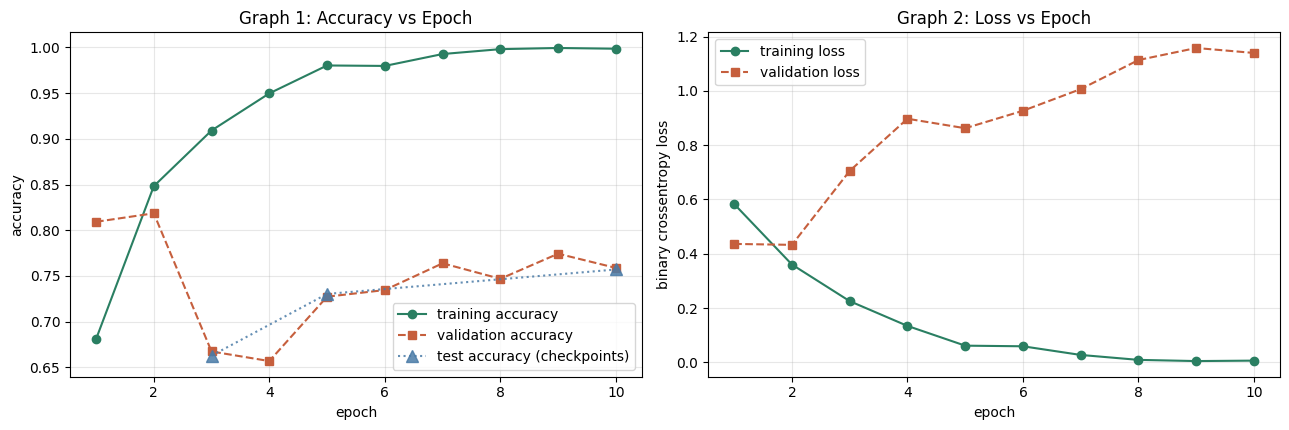

best validation accuracy at epoch 2: 0.8185
final train/validation gap: +0.2396


In [ ]:
h = history.history
ep = range(1, len(h['accuracy'])+1)
te_ep  = [r['epoch']    for r in tracker.rows if r['test_acc'] == r['test_acc']]
te_val = [r['test_acc'] for r in tracker.rows if r['test_acc'] == r['test_acc']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(ep, h['accuracy'], 'o-', label='training accuracy', color='#2a7f62')
axes[0].plot(ep, h['val_accuracy'], 's--', label='validation accuracy', color='#c65f3d')
axes[0].plot(te_ep, te_val, '^:', label='test accuracy (checkpoints)', color='#4a7ba7', alpha=0.85, markersize=9)
axes[0].set_title("Graph 1: Accuracy vs Epoch"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, h['loss'], 'o-', label='training loss', color='#2a7f62')
axes[1].plot(ep, h['val_loss'], 's--', label='validation loss', color='#c65f3d')
axes[1].set_title("Graph 2: Loss vs Epoch"); axes[1].set_xlabel("epoch")
axes[1].set_ylabel("binary crossentropy loss"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

best = int(np.argmax(h['val_accuracy'])) + 1
print(f"best validation accuracy at epoch {best}: {max(h['val_accuracy']):.4f}")
print(f"final train/validation gap: {h['accuracy'][-1] - h['val_accuracy'][-1]:+.4f}")

#### Observation
**Graph 1 (accuracy).** Training accuracy rises almost monotonically to 0.9984. Validation peaks at epoch 2 and then separates from it, and that widening gap is overfitting. The three test checkpoints (0.6629, 0.7304, 0.7571) track the validation curve closely, dip included, so the validation split is a faithful stand-in for the test set here.

**Graph 2 (loss).** Training loss falls every epoch, while validation loss bottoms out at epoch 2 and climbs for the rest of the run. That divergence is the clearest overfitting signature in the notebook, and it marks epoch 2 as where early stopping should have ended training.

**One detail worth noticing.** From epoch 5 to epoch 9, validation accuracy *rises* (0.7274 to 0.7743) while validation loss also *rises* (0.8624 to 1.1581). Accuracy only counts right and wrong, but crossentropy punishes confident mistakes heavily. As the model overfits it becomes more certain about everything, so the reviews it still gets wrong are wrong with high confidence, and the loss grows even as the error count shrinks.

**Convergence:** unstable rather than smooth. A 15.1 point validation drop in one epoch is far beyond normal epoch-to-epoch noise, and a sign of how hard SimpleRNN training is on 200-step sequences.

## Task 7: Hyperparameter experimentation

Experiment B comes from the 10-epoch run above. Experiments A and C need the additional configurations; the `units=64, batch=64` cell is shared between all three experiments and is not retrained.

In [ ]:
results = {}
for r in tracker.rows:
    if r['epoch'] in (3, 5, 10):
        results[f"B{[3, 5, 10].index(r['epoch']) + 1}"] = dict(
            param=f"Epochs = {r['epoch']}", train=r['train_acc'], val=r['val_acc'], test=r['test_acc'])

# units=64, batch=64, 5 epochs is the main run at epoch 5, shared by A2 and C2
ref5 = dict(train=ep5['train_acc'], val=ep5['val_acc'], test=ep5['test_acc'], secs=time_5ep)
results['A2'] = dict(param="RNN units = 64", **ref5)
results['C2'] = dict(param="Batch size = 64", **ref5)

def show(tag, note=""):
    r = results[tag]
    print(f"{tag:<4}{r['param']:<20} train {r['train']:.4f}  val {r['val']:.4f}  "
          f"test {r['test']:.4f}  ({r['secs']:.0f}s){note}")

def run_config(tag, param, units=64, batch=64, epochs=5):
    m = build_rnn(units=units)
    t0 = time.time()
    hh = m.fit(X_train, y_train, epochs=epochs, batch_size=batch, validation_split=0.2, verbose=0)
    secs = time.time() - t0
    te = m.evaluate(X_test, y_test, verbose=0)[1]
    results[tag] = dict(param=param, train=hh.history['accuracy'][-1],
                        val=hh.history['val_accuracy'][-1], test=te, secs=secs)
    show(tag)

print("Experiment A: RNN units (5 epochs, batch 64)")
run_config('A1', "RNN units = 32", units=32)
show('A2', "  main run, not retrained")
run_config('A3', "RNN units = 128", units=128)

print("\nExperiment C: batch size (5 epochs, 64 units)")
run_config('C1', "Batch size = 32", batch=32)
show('C2', "  main run, not retrained")
run_config('C3', "Batch size = 128", batch=128)

Experiment A: RNN units (5 epochs, batch 64)


A1  RNN units = 32       train 0.9948  val 0.7143  test 0.7069  (87s)
A2  RNN units = 64       train 0.9801  val 0.7274  test 0.7304  (92s)  main run, not retrained


A3  RNN units = 128      train 0.8634  val 0.7750  test 0.7746  (103s)

Experiment C: batch size (5 epochs, 64 units)


C1  Batch size = 32      train 0.8257  val 0.7391  test 0.7442  (206s)
C2  Batch size = 64      train 0.9801  val 0.7274  test 0.7304  (92s)  main run, not retrained


C3  Batch size = 128     train 0.9851  val 0.7637  test 0.7582  (103s)


### Results table

In [ ]:
print(f"{'Experiment':<12}{'Parameter':<22}{'Training Acc':>14}{'Validation Acc':>16}{'Test Acc':>11}")
print("-"*75)
for tag in ['A1','A2','A3','B1','B2','B3','C1','C2','C3']:
    r = results[tag]
    print(f"{tag:<12}{r['param']:<22}{r['train']:>14.4f}{r['val']:>16.4f}{r['test']:>11.4f}")

print(f"\nbest test accuracy : {max(results.items(), key=lambda kv: kv[1]['test'])[0]} "
      f"({max(r['test'] for r in results.values()):.4f})")
print(f"spread across all 9 : {max(r['test'] for r in results.values()) - min(r['test'] for r in results.values()):.4f}")

Experiment  Parameter               Training Acc  Validation Acc   Test Acc
---------------------------------------------------------------------------
A1          RNN units = 32                0.9948          0.7143     0.7069
A2          RNN units = 64                0.9801          0.7274     0.7304
A3          RNN units = 128               0.8634          0.7750     0.7746
B1          Epochs = 3                    0.9090          0.6675     0.6629
B2          Epochs = 5                    0.9801          0.7274     0.7304
B3          Epochs = 10                   0.9984          0.7588     0.7571
C1          Batch size = 32               0.8257          0.7391     0.7442
C2          Batch size = 64               0.9801          0.7274     0.7304
C3          Batch size = 128              0.9851          0.7637     0.7582

best test accuracy : A3 (0.7746)
spread across all 9 : 0.1117


#### Observation
Answering the table first, then reading it critically.

- **Units (A):** test accuracy rose with units, 0.7069, 0.7304, 0.7746. 128 units is the best result in the table.
- **Epochs (B):** test accuracy rose with epochs, 0.6629, 0.7304, 0.7571.
- **Batch size (C):** no clean trend, 0.7442, 0.7304, 0.7582. Batch 32 took 206s against 92 to 103s for the larger batches, since it makes twice as many weight updates per epoch.

**Why I do not trust those trends.** Experiment B is one model measured at three checkpoints, and its test accuracy moves **9.42 points** between epochs 3 and 10 with no hyperparameter changing at all. The spread across all nine configurations is **11.17 points**. The differences between configurations are barely larger than the swing inside a single run, so this table mostly records where each unstable run happened to be when it stopped, not what the hyperparameter did.

Experiment B shows it directly: more epochs "improved" test accuracy while training accuracy approached 100% and validation loss kept rising. More training did not help this model; epoch 3 was simply a trough. The training accuracy column agrees, with runs at the same 5 epochs anywhere from 0.8257 to 0.9948, meaning they sit at completely different stages of the same overfitting process.

(The batch-64 time comes from the main run's per-epoch timer and the others from timing the whole `fit` call, so differences of ten seconds or so are not meaningful.)

## Does the RNN actually use word order?

An RNN practical ought to answer this, and none of the required experiments does.

An RNN's justification over a bag-of-words model is that it processes sequence. The bag-of-words baseline above ignores order completely, so comparing the two tells us whether order is **useful for this task**. It does not tell us whether the RNN is **using** it.

The direct test: shuffle the words within each review, keeping the padding in place and the label unchanged, then train the identical model on the scrambled text. If accuracy is unaffected, the RNN was never relying on order and is acting as an expensive bag of words. If accuracy collapses, order is load-bearing.

Same structure as the fixed-position defect test in Practical 5: two explanations compete, so build the test that separates them. Trained for 3 epochs and compared against the main run's own epoch-3 test accuracy, so the comparison is matched rather than approximate.

In [ ]:
def shuffle_within_review(X, seed=0):
    rng = np.random.default_rng(seed)
    out = X.copy()
    for i in range(len(out)):
        nz = np.flatnonzero(out[i] > 0)          # real tokens only, padding stays put
        if len(nz) > 1:
            out[i, nz] = rng.permutation(out[i, nz])
    return out

X_train_sh, X_test_sh = shuffle_within_review(X_train, 0), shuffle_within_review(X_test, 1)
print("original word ids :", X_train[0][-14:])
print("shuffled word ids :", X_train_sh[0][-14:])

m_sh = build_rnn(units=64)
m_sh.fit(X_train_sh, y_train, epochs=3, batch_size=64, validation_split=0.2, verbose=0)
sh_acc = m_sh.evaluate(X_test_sh, y_test, verbose=0)[1]
ordered_acc = tracker.rows[2]['test_acc']   # epoch 3 of the main run, same epoch count

print(f"\n{'RNN, word order preserved (3 ep)':<36}{ordered_acc:.4f}")
print(f"{'RNN, word order destroyed (3 ep)':<36}{sh_acc:.4f}")
print(f"{'bag-of-words (ignores order)':<36}{bow_acc:.4f}")
print(f"\ncost of destroying word order: {100*(ordered_acc - sh_acc):+.2f} percentage points")

original word ids : [   5 1432  532   17   69   16    3  338   86   37  111  618   12 9067]
shuffled word ids : [  68 1580 9067    2 4323   11    2  269  377 3317   13 1793    6 2020]



RNN, word order preserved (3 ep)    0.6629
RNN, word order destroyed (3 ep)    0.7026
bag-of-words (ignores order)        0.8750

cost of destroying word order: -3.97 percentage points


#### Observation
Neither of the outcomes I set up. **The scrambled reviews scored 3.97 points higher** (0.7026 against 0.6629).

Scrambling word order cannot genuinely help a model read a review, so this is not a real effect. It is the instability from the training curves showing through. The ordered model was measured at epoch 3, exactly where its validation accuracy had just dropped 15.1 points in one epoch. Matching the epoch count made the comparison look fair, but when a single model swings by more than the effect being measured, one checkpoint per condition cannot separate the two.

So this test, as designed, **does not answer** whether the SimpleRNN uses word order. Answering it properly needs several seeds per condition and a comparison of each run's best validation accuracy rather than one checkpoint. Practical 5's position test worked because the CNN trained stably; a controlled experiment is only as good as the stability of the thing being measured.

What the notebook *can* say is that order is not what drives accuracy on this dataset. The bag-of-words model uses no order at all and scores 0.8750, higher than every recurrent model in this notebook, including the GRU and LSTM further down.

## Task 9: The two-layer RNN, and what `return_sequences=True` does

**The mechanics first.** A `SimpleRNN` reads 200 timesteps and, by default, returns only the **final** hidden state, a single vector of 64 numbers. That is what you want feeding a Dense classifier, but it is useless as input to a second RNN, which needs a sequence to read.

`return_sequences=True` makes the layer return the hidden state at **every** timestep instead, shape `(batch, 200, 64)` rather than `(batch, 64)`. The second RNN then reads that 200-step sequence of hidden states the way the first read the 200-step sequence of word embeddings.

So the first layer must have `return_sequences=True` and the last must not. Getting this wrong is the standard error: without it the second layer receives a single vector where it expects a sequence, and Keras raises a shape error.

In [ ]:
m_deep = build_rnn(units=64, layers=2)
m_deep.summary()

t0 = time.time()
h_deep = m_deep.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2, verbose=0)
deep_time = time.time() - t0
deep_acc = m_deep.evaluate(X_test, y_test, verbose=0)[1]
one_layer_acc = ep5['test_acc']          # the main run at epoch 5: same epochs, batch and seed

print(f"\n{'model':<20}{'params':>10}{'train acc':>11}{'test acc':>10}{'time (5 ep)':>13}")
print("-"*64)
print(f"{'1-layer SimpleRNN':<20}{model.count_params():>10,}{ep5['train_acc']:>11.4f}"
      f"{one_layer_acc:>10.4f}{time_5ep:>12.0f}s")
print(f"{'2-layer SimpleRNN':<20}{m_deep.count_params():>10,}{h_deep.history['accuracy'][-1]:>11.4f}"
      f"{deep_acc:>10.4f}{deep_time:>12.0f}s")
print(f"\ndifference: {100*(deep_acc - one_layer_acc):+.2f} percentage points, "
      f"{deep_time/time_5ep:.2f}x the training time")

Model: "simple_rnn_64u_2layer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,300,673 (4.96 MB)

 Trainable params: 1,300,673 (4.96 MB)

 Non-trainable params: 0 (0.00 B)


model                   params  train acc  test acc  time (5 ep)
----------------------------------------------------------------
1-layer SimpleRNN    1,292,417     0.9801    0.7304          92s
2-layer SimpleRNN    1,300,673     0.9354    0.7748         207s

difference: +4.44 percentage points, 2.23x the training time


#### Observation
**Which model gives better test accuracy?** The two-layer model, 0.7748 against 0.7304, a gain of 4.44 points.

**Which takes longer to train?** The two-layer model, 207s against 92s for 5 epochs, 2.23 times as long. The second layer adds only 8,256 parameters, under 1% more, so the cost is not size. It is a second 200-step loop: each timestep of layer 2 needs layer 1's output at that step, so the extra work cannot be parallelised across time.

**Does adding a layer always improve performance?** No, and here the gain cannot even be credited to depth with confidence. It is smaller than the 9.42 point swing one model showed between checkpoints, and the two-layer model was less overfit at epoch 5 (training accuracy 0.9354 against 0.9801), which alone could explain it. Stacking SimpleRNNs also lengthens the path gradients have to travel, which worsens vanishing gradients, so deeper SimpleRNN stacks are often harder to train rather than easier.

**What is the purpose of `return_sequences=True`?** It makes the first layer output its hidden state at all 200 timesteps, shape `(None, 200, 64)` in the summary above, instead of only the final state `(None, 64)`. The second RNN needs a sequence to read; without the flag it would receive one vector and Keras would raise a shape error.

## Why LSTM exists: SimpleRNN against GRU and LSTM

Discussion questions 6 and 10 ask about the vanishing-gradient problem and how LSTM and GRU differ from SimpleRNN. Rather than only describe the difference, the three cells are compared directly on this dataset.

**The problem.** A SimpleRNN's hidden state is recomputed at every timestep as `h_t = tanh(W x_t + U h_(t-1) + b)`. To learn from a word 200 steps back, the gradient has to travel back through 200 multiplications by `U` and 200 tanh derivatives. Tanh's derivative is at most 1 and usually well below it, so the gradient shrinks geometrically. In practice a SimpleRNN struggles to connect evidence separated by more than a few dozen steps.

**LSTM** adds a separate cell state that is updated by addition rather than repeated multiplication, plus gates that learn what to keep, forget and output. The additive path lets gradients survive far longer. **GRU** is a lighter version with two gates instead of three and no separate cell state, so it is cheaper with usually similar accuracy.

**The test:** identical architecture and training (3 epochs, seed 42, batch 64, 64 units), only the recurrent cell changes. The SimpleRNN row is the main run at epoch 3, which is exactly that configuration, so it is reused rather than retrained.

In [ ]:
cell_results = {'simple': dict(acc=tracker.rows[2]['test_acc'], secs=time_3ep,
                               params=model.count_params())}
print(f"{'SIMPLE':<8}test accuracy {cell_results['simple']['acc']:.4f}   "
      f"params {model.count_params():>9,}   {time_3ep:>4.0f}s   (main run at epoch 3)")
for cell in ['gru', 'lstm']:
    mc = build_rnn(units=64, cell=cell)
    t0 = time.time()
    mc.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2, verbose=0)
    secs = time.time() - t0
    acc = mc.evaluate(X_test, y_test, verbose=0)[1]
    cell_results[cell] = dict(acc=acc, secs=secs, params=mc.count_params())
    print(f"{cell.upper():<8}test accuracy {acc:.4f}   params {mc.count_params():>9,}   {secs:>4.0f}s")

print(f"\nbag-of-words baseline for reference: {bow_acc:.4f}")

SIMPLE  test accuracy 0.6629   params 1,292,417     57s   (main run at epoch 3)


GRU     test accuracy 0.8566   params 1,317,313    124s


LSTM    test accuracy 0.8438   params 1,329,473    124s

bag-of-words baseline for reference: 0.8750


#### Observation
After only 3 epochs, **GRU reaches 0.8566 and LSTM 0.8438**, against 0.6629 for the SimpleRNN at the same point.

That comparison flatters the gated cells, because epoch 3 was the SimpleRNN's worst checkpoint. The fair comparison is against the best SimpleRNN result anywhere in this notebook, 0.7748 from the two-layer model. GRU still beats it by 8.18 points and LSTM by 6.90, with fewer epochs.

This is consistent with the vanishing-gradient explanation: the gated cells' additive memory path lets the training signal reach early words that a SimpleRNN effectively cannot learn from. The cost is speed, about 2.2 times slower (124s against 57s over 3 epochs), for only 2 to 3% more parameters. GRU matches LSTM with fewer parameters, which is the usual argument for trying it first.

**And the bag-of-words baseline still wins, at 0.8750.** Better recurrent cells close most of the gap to a model that ignores order entirely, but none of them overtakes it within this training budget.

## Task 8: Predicting on new reviews

A function that takes raw text, applies the identical preprocessing pipeline, and returns a sentiment with its probability. The five reviews below are my own, written to cover easy and awkward cases rather than five obvious ones.

In [ ]:
def predict_sentiment(text, trained_model=None):
    trained_model = trained_model if trained_model is not None else model
    seq = encode(tokenize(text))
    padded = pad_sequences_manual([seq])
    p = float(trained_model.predict(padded, verbose=0).ravel()[0])
    return ("Positive" if p >= 0.5 else "Negative"), p

my_reviews = [
    ("An absolute masterpiece. The performances were stunning and the ending left me speechless.", "Positive"),
    ("Painfully boring. I checked my watch four times and walked out before the end.", "Negative"),
    ("The visuals are gorgeous and the soundtrack is wonderful, easily worth the ticket.", "Positive"),
    ("A complete waste of money. Terrible script, wooden acting, and a plot that made no sense.", "Negative"),
    ("Not the kind of film I usually enjoy, but I was completely won over by the second half.", "Positive"),
]

print(f"{'#':<3}{'Expected':<11}{'Predicted':<11}{'Probability':>12}{'  Review'}")
print("-"*104)
correct = 0
for i,(txt, expected) in enumerate(my_reviews, 1):
    pred, prob = predict_sentiment(txt)
    correct += (pred == expected)
    print(f"{i:<3}{expected:<11}{pred:<11}{prob:>12.4f}  {txt[:56]}...")
print(f"\ncorrect: {correct} of {len(my_reviews)}")

#  Expected   Predicted   Probability  Review
--------------------------------------------------------------------------------------------------------
1  Positive   Positive         0.9968  An absolute masterpiece. The performances were stunning ...


2  Negative   Negative         0.0020  Painfully boring. I checked my watch four times and walk...
3  Positive   Positive         1.0000  The visuals are gorgeous and the soundtrack is wonderful...
4  Negative   Negative         0.0007  A complete waste of money. Terrible script, wooden actin...
5  Positive   Negative         0.1612  Not the kind of film I usually enjoy, but I was complete...

correct: 4 of 5


#### Observation
**4 of 5 correct**, and the four correct ones are confident: 0.9968, 0.0020, 1.0000 and 0.0007.

The miss is review 5, predicted Negative at 0.1612, so a confident miss rather than a borderline one. It is also the one review I wrote to need more than vocabulary. Its first half is a denial ("Not the kind of film I usually enjoy"), and the positive verdict exists only because "but" overrides what came before. Reviews 1 to 4 can be classified from their words alone; review 5 cannot.

That is exactly the case a sequence model is supposed to handle better than bag of words, and the SimpleRNN did not. It fits the rest of the notebook: this model mostly learned which words appear, not how clauses combine.

## Discussion questions

**1. What is an RNN, and why does it suit text classification?**
A network that reads a sequence one element at a time and passes a hidden state from each step to the next, so its output depends on everything it has read and in what order. Reviews vary in length and word order carries meaning ("not good" against "good"), which is exactly that shape. The same weights are applied at every step, so a pattern learned at one position is recognised at any other.

**2. What is the purpose of the Embedding layer?**
Word ids are arbitrary labels: 4821 is not "more" than 12 in any sense. The Embedding layer is a trainable 10,000 x 128 lookup table that turns each id into a dense vector, and training pulls words used in similar ways toward similar vectors. One-hot encoding would need 10,000 inputs per word instead of 128.

**3. Why is padding required?**
A batch is processed as one tensor, so every review must have the same length. Reviews here run up to 2,247 tokens, so each is truncated or zero-padded to 200. Padding at the front keeps the real words closest to the final hidden state the classifier reads.

**4. Why is sigmoid used in the output layer?**
With two classes, one number is enough: the probability the review is positive. Sigmoid maps any real value into (0, 1), so the output reads directly as that probability and is thresholded at 0.5.

**5. Why binary cross-entropy?**
It is the loss that matches one sigmoid probability, `-[y log p + (1-y) log(1-p)]`. It charges `-log` of the probability given to the correct class, so confident mistakes cost far more than unsure ones, which is why validation loss rose here even while validation accuracy recovered.

**6. What is the vanishing-gradient problem?**
Backpropagating through an RNN multiplies the gradient by the recurrent weights and the tanh derivative once per timestep. Over 200 steps those factors, usually below 1, compound geometrically, so almost no training signal reaches the early words. Practical 6 measured the same mechanism over just two layers, where sigmoid's first-layer gradient was 14.5 times weaker than ReLU's; here the chain is 200 steps long.

**7. What happens when the number of RNN units increases?**
The hidden state can carry more information, and the recurrent weights grow with the square of the units. Test accuracy rose from 0.7069 at 32 units to 0.7746 at 128, and training time from 87s to 103s. But the 128-unit run was far less overfit at epoch 5 (training accuracy 0.8634 against 0.9948), so the gain may be slower overfitting rather than useful capacity. More units do not always help.

**8. What is overfitting?**
A model improving on its training data while getting worse on unseen data, because it memorises examples instead of learning patterns that transfer. Here, training accuracy reached 0.9984 against 0.7571 on test.

**9. How can overfitting be reduced in an RNN?**
Early stopping at the best validation epoch (epoch 2 here), dropout on the inputs and the recurrent connections (`SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2)`), L2 weight regularisation, a smaller embedding (it holds 99% of the parameters here), and more training data.

**10. What is the difference between SimpleRNN, LSTM and GRU?**
SimpleRNN overwrites its hidden state at every step, so old information fades and gradients vanish. LSTM adds a separate cell state updated by addition, with input, forget and output gates deciding what to keep. GRU folds this into two gates (update and reset) with no separate cell state, so it is lighter with similar accuracy. After 3 epochs here: SimpleRNN 0.6629, GRU 0.8566, LSTM 0.8438.

### Personal notes

**The experiment I designed as the centrepiece failed, and it is the most useful thing in this notebook.** I built the word-order test to separate two explanations, matched it carefully to epoch 3, and got a result that cannot be real: scrambled text scoring higher. The wrong response would have been to rerun it until it looked sensible. The right one was to ask how a matched comparison could fail, and the answer was already sitting in the training curves: this model swings 15 points between consecutive epochs.

**Same lesson as Practical 7, reached from a different direction.** There the noise came from changing the random seed. Here it comes from changing the stopping epoch inside a single run. Either way, a comparison only means something once you know how much the thing being compared moves on its own.

**The baseline surprised me most.** I expected the recurrent models to beat bag of words comfortably. Plain logistic regression on word presence beat all of them, GRU and LSTM included. On movie reviews, sentiment lives mostly in the vocabulary.

**Building the tokeniser by hand was worth it.** `load_data()` would have handed me integers. Doing it manually showed that 11% of the distinct words cover 94% of all word occurrences, and that 99% of the model ends up as the embedding table, which is what made the overfitting make sense.

**What I would do next:** add early stopping and recurrent dropout, then redo the word-order test properly, with several seeds per condition and each run's best validation accuracy compared instead of a single checkpoint.

#### Conclusion
This practical built a SimpleRNN sentiment classifier on 49,582 IMDB reviews, with every tokenisation step done explicitly rather than hidden inside `load_data()`. It reached 0.7304 test accuracy at the specified 5 epochs and 0.7571 after 10, well below a bag-of-words logistic regression at 0.8750 that ignores word order entirely.

The best result in the table came from 128 units, at 0.7746. More units and more epochs both raised test accuracy on paper, but one model's test accuracy moved 9.42 points between epochs 3 and 10 alone, close to the 11.17 point spread across all nine configurations, so those rankings mostly record where each unstable run stopped. The main limitations were heavy overfitting after epoch 2, with training accuracy reaching 0.9984 while validation loss rose 2.6 times, and instability severe enough to invalidate a single-checkpoint word-order test.

GRU and LSTM address the core weakness directly. After only 3 epochs they reached 0.8566 and 0.8438, above every SimpleRNN configuration, because gated, additive memory lets gradients reach early words. Early stopping and recurrent dropout would be the next improvements.